# 00_11 — Regresión PSBP sobre Componentes de la representación funcional

**Objetivo:** Modelar la dinámica temporal de los coeficientes B-spline mediante regresiones
AR(p) con modelo PSBP por componente, estandarizando previamente las curvas funcionales y
verificando la convergencia del MCMC mediante un conjunto completo de diagnósticos.

## Pipeline

```
FAR(1) simulado  ──►  X ∈ ℝ^{T×G}
       ↓
Estandarización por columna (z-score a lo largo de t para cada s_g)
       ↓
B-spline   ──►  Θ ∈ ℝ^{T×K}
       ↓
Para cada componente k y cada cadena c=1..C:
    θ_{t,k} = α_k + Σ β_{k,j,l} · γ_{k,j,l} · θ_{t-l,j} + ε_{t,k}   (PSBP_FD_v2)
       ↓
Diagnósticos: trazas, ACF, ESS, Geweke, Gelman-Rubin R̂
       ↓
Evaluación: RMSE, P(γ=1), reconstrucción funcional
       ↓
Persistencia: figuras PNG + métricas JSON + config JSON
```

| Rol | Ruta |
|-----|------|
| Datos simulados | `data/simulaciones/raw/` |
| Predicciones | `data/simulaciones/processed/predict/` |
| Figuras | `reports/simulaciones/figures/` |
| Métricas | `reports/simulaciones/metrics/` |


# 1. Imports y rutas

In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
import os
import sys
from pathlib import Path
from datetime import datetime
import time

from model_psbp_fd.pipelines import (
    FunctionalDomain,
    FARSimulator,
    gaussian_integral_kernel,
    build_integral_matrix,
)
from model_psbp_fd.functions_models import FunctionalRepresentation
from model_psbp_fd.models.psbp_fd_v2.psbp_fd_v2 import PSBP_FD_v2

# ── Módulos de visualización ──────────────────────────────────────────────────
# Apunta al paquete graphics/ que está dentro del proyecto
SYS_PATH_GRAPHICS = Path("graphics")
if str(SYS_PATH_GRAPHICS) not in sys.path:
    sys.path.insert(0, str(SYS_PATH_GRAPHICS))

from model_psbp_fd.graphics import (
    # viz_traces
    plot_traces_bj, plot_traces_pj,
    plot_convergence_bj, plot_convergence_pj,
    # viz_global_components
    plot_global_components, plot_active_clusters,
    # viz_functional_data
    plot_empirical_sample, plot_functional_mean,
    plot_functional_variance, plot_mean_and_variance,
    # viz_time_series
    plot_fts_empirical, plot_fts_functional, plot_fts_comparison,
    # viz_prediction
    plot_scatter_theta, plot_functional_comparison,
)

plt.style.use("seaborn-v0_8-darkgrid")
%matplotlib inline

In [31]:
# ── Raíz del proyecto ─────────────────────────────────────────────────────────
def get_project_root(marker: str = "README.md") -> Path:
    current = Path(os.getcwd()).resolve()
    for parent in [current] + list(current.parents):
        if (parent / marker).exists():
            return parent
    return current

PROJECT_ROOT = get_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))
print(f"PROJECT_ROOT : {PROJECT_ROOT}")

# ── Identificación del experimento ────────────────────────────────────────────
# Debe definirse ANTES de PATHS porque la carpeta de salida lleva el ID.
BASENAME      = "FAR_lineal_st_nuevo_modelo"
TT            = 2
SEED          = 4123
TIMESTAMP     = datetime.now().strftime("%Y%m%d_%H%M%S")
EXPERIMENT_ID = f"convergencia_{BASENAME}_{TT}_{TIMESTAMP}"
print(f"Experiment ID : {EXPERIMENT_ID}")
print(f"Seed (base)   : {SEED}")

# ── Rutas canónicas ───────────────────────────────────────────────────────────
# Todas las salidas (figuras + JSONs) van dentro de:
#   reports/simulaciones/{EXPERIMENT_ID}/
# Los datos brutos van en data/simulaciones/raw/ (sin subcarpeta por experimento).
_REPORT_DIR = PROJECT_ROOT / "reports" / "simulaciones" / EXPERIMENT_ID

PATHS = {
    "raw":     PROJECT_ROOT / "data" / "simulaciones" / "raw",
    "predict": PROJECT_ROOT / "data" / "simulaciones" / "processed" / "predict",
    "out":     _REPORT_DIR,           # raíz del experimento
}
for name, path in PATHS.items():
    path.mkdir(parents=True, exist_ok=True)
    print(f"  {name:10s} → {path}")

PROJECT_ROOT : C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd
Experiment ID : convergencia_FAR_lineal_st_nuevo_modelo_2_20260515_113936
Seed (base)   : 4123
  raw        → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\raw
  predict    → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\data\simulaciones\processed\predict
  out        → C:\Users\JuanFran\Desktop\git_tesis\model_psbp_fd\reports\simulaciones\convergencia_FAR_lineal_st_nuevo_modelo_2_20260515_113936


# 2. Simulación y estandarización

## 2.1 Parámetros e identificación del experimento

In [32]:
FAR_PARAMS = {
    "n_curves":       100,
    "n_points":       100,
    "bandwidth":      0.05,
    "decay":          0.8,
    "temporal_slope": 4.0,
    "spatial_slope":  2.0,
    "intercept":      1.0,
    "noise_std":      0.2,
    "noise_type":     "smooth",
    "burn_in":        100,
}
for k, v in FAR_PARAMS.items():
    print(f"  {k:<18}: {v}")

  n_curves          : 100
  n_points          : 100
  bandwidth         : 0.05
  decay             : 0.8
  temporal_slope    : 4.0
  spatial_slope     : 2.0
  intercept         : 1.0
  noise_std         : 0.2
  noise_type        : smooth
  burn_in           : 100


## 2.2 Simulación FAR(1)

In [33]:
domain = FunctionalDomain.regular(n_points=FAR_PARAMS["n_points"])
Psi    = build_integral_matrix(
    domain, gaussian_integral_kernel,
    bandwidth=FAR_PARAMS["bandwidth"],
    decay=FAR_PARAMS["decay"],
)

sim = FARSimulator(
    domain=domain,
    n_curves=FAR_PARAMS["n_curves"],
    Psi=Psi,
    trend="linear",
    trend_params={
        "temporal_slope": FAR_PARAMS["temporal_slope"],
        "spatial_slope":  FAR_PARAMS["spatial_slope"],
        "intercept":      FAR_PARAMS["intercept"],
    },
    noise_std=FAR_PARAMS["noise_std"],
    noise_type=FAR_PARAMS["noise_type"],
    burn_in=FAR_PARAMS["burn_in"],
    random_state=SEED,
)
X_raw = sim.simulate()   # (T, G)
T, G  = X_raw.shape
print(f"Datos simulados : {X_raw.shape}  →  T={T} curvas, G={G} puntos")

Datos simulados : (100, 100)  →  T=100 curvas, G=100 puntos


## 2.3 Visualización de los datos empíricos

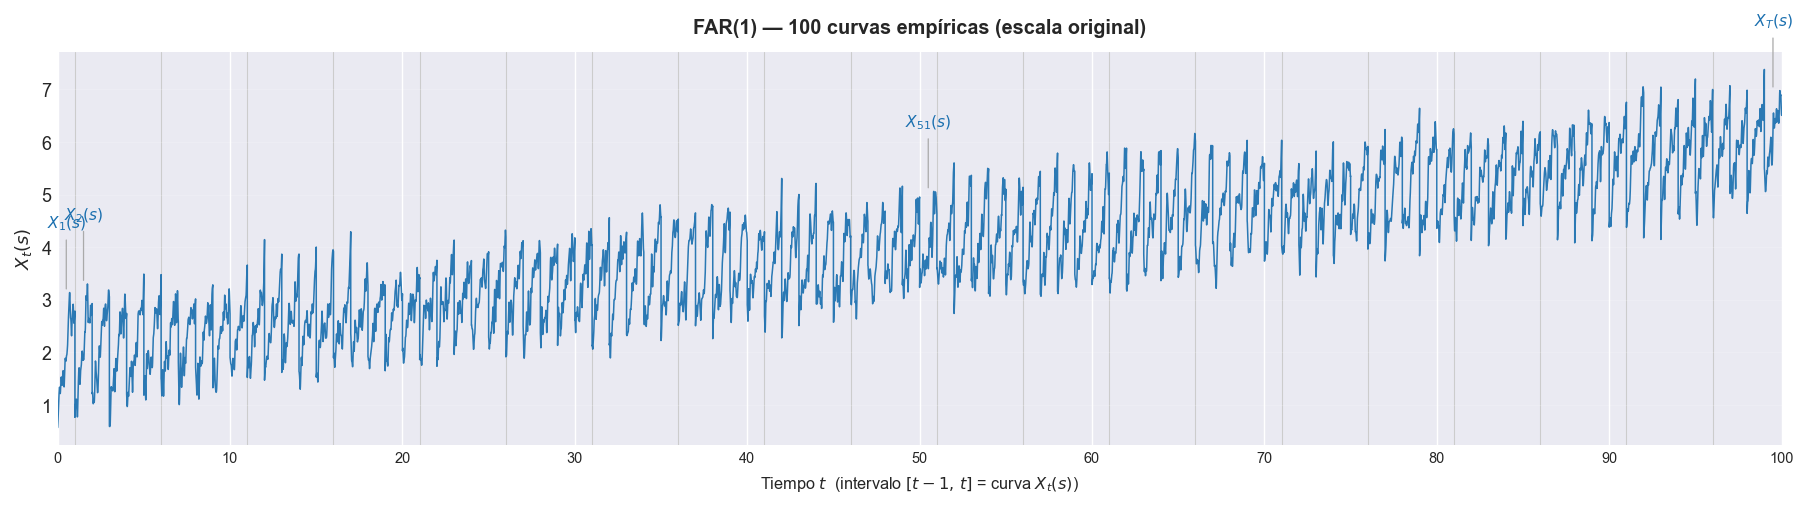

In [35]:
# ── Serie de tiempo funcional empírica (línea continua desplazada) ────────────
highlight_idx = [0, 1, sim.n_curves // 2, sim.n_curves - 1]

fig = plot_fts_empirical(
    X_raw, domain.grid,
    highlight_idx   = highlight_idx,
    title           = f"FAR(1) — {T} curvas empíricas (escala original)",
    separator_every = 5,
    save_path       = str(PATHS["out"] / "01_fts_empirica_raw.png"),
)
plt.show()

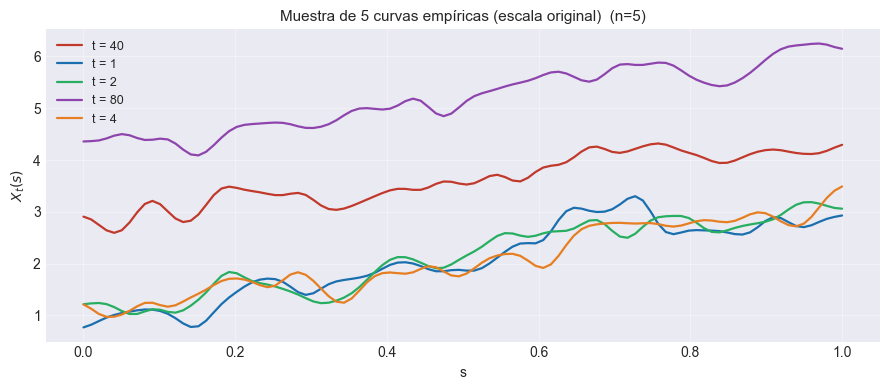

In [36]:
# ── Muestra de curvas empíricas (5 índices fijos) ─────────────────────────────
fig = plot_empirical_sample(
    X_raw, domain.grid,
    sample_idx = [40, 1, 2, 80, 4],
    title      = "Muestra de 5 curvas empíricas (escala original)",
    save_path  = str(PATHS["out"] / "02_muestra_empirica_raw.png"),
)
plt.show()

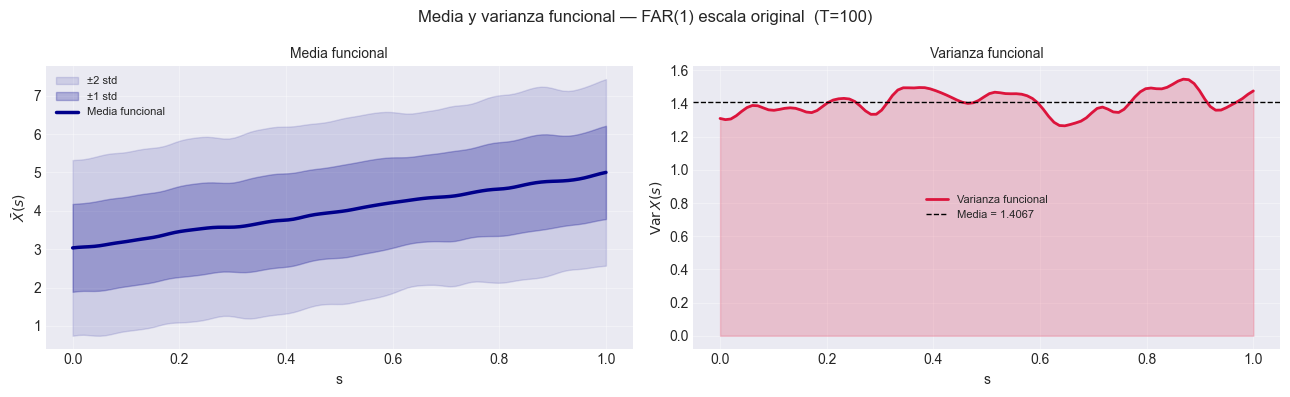

In [37]:
# ── Media y varianza funcional (panel combinado) ──────────────────────────────
fig = plot_mean_and_variance(
    X_raw, domain.grid,
    show_std1 = True,
    show_std2 = True,
    title     = "Media y varianza funcional — FAR(1) escala original",
    save_path = str(PATHS["out"] / "03_media_varianza_raw.png"),
)
plt.show()

## 2.4 Estandarización por columna (z-score)

In [38]:
STANDARIZE_CONFIG = {"method": "zscore_column", "ddof": 0, "store_stats": True}

X_mean = X_raw.mean(axis=0)
X_std  = X_raw.std(axis=0, ddof=STANDARIZE_CONFIG["ddof"])

if np.any(X_std == 0):
    raise ValueError(f"Columnas con varianza nula: {np.where(X_std == 0)[0].tolist()}")

X = (X_raw - X_mean) / X_std
print(f"X estandarizada : shape={X.shape}")
print(f"  max|media|  = {np.abs(X.mean(axis=0)).max():.2e}  (debe ≈ 0)")
print(f"  max|std-1|  = {np.abs(X.std(axis=0) - 1).max():.2e}  (debe ≈ 0)")

X estandarizada : shape=(100, 100)
  max|media|  = 2.64e-15  (debe ≈ 0)
  max|std-1|  = 4.44e-16  (debe ≈ 0)


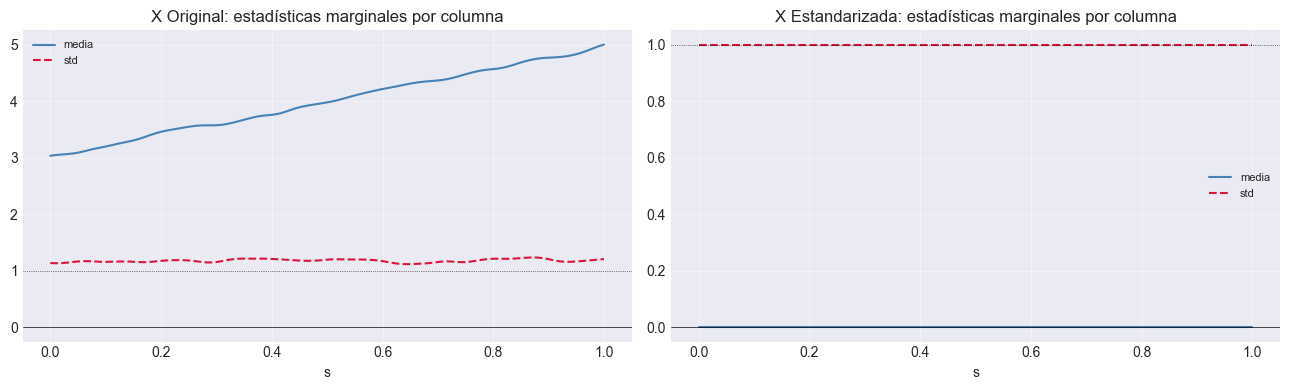

In [39]:
# ── Diagnóstico visual de estandarización ────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax, Xp, lbl in zip(axes, [X_raw, X], ["Original", "Estandarizada"]):
    ax.plot(domain.grid, Xp.mean(axis=0), color="steelblue", lw=1.5, label="media")
    ax.plot(domain.grid, Xp.std(axis=0),  color="crimson",   lw=1.5, ls="--", label="std")
    ax.axhline(0, color="k", lw=0.5)
    ax.axhline(1, color="k", lw=0.5, ls=":")
    ax.set_title(f"X {lbl}: estadísticas marginales por columna")
    ax.set_xlabel("s"); ax.legend(fontsize=8); ax.grid(True, alpha=0.4)

plt.tight_layout()
fig.savefig(PATHS["out"] / "04_diagnostico_estandarizacion.png", dpi=130, bbox_inches="tight")
plt.show()

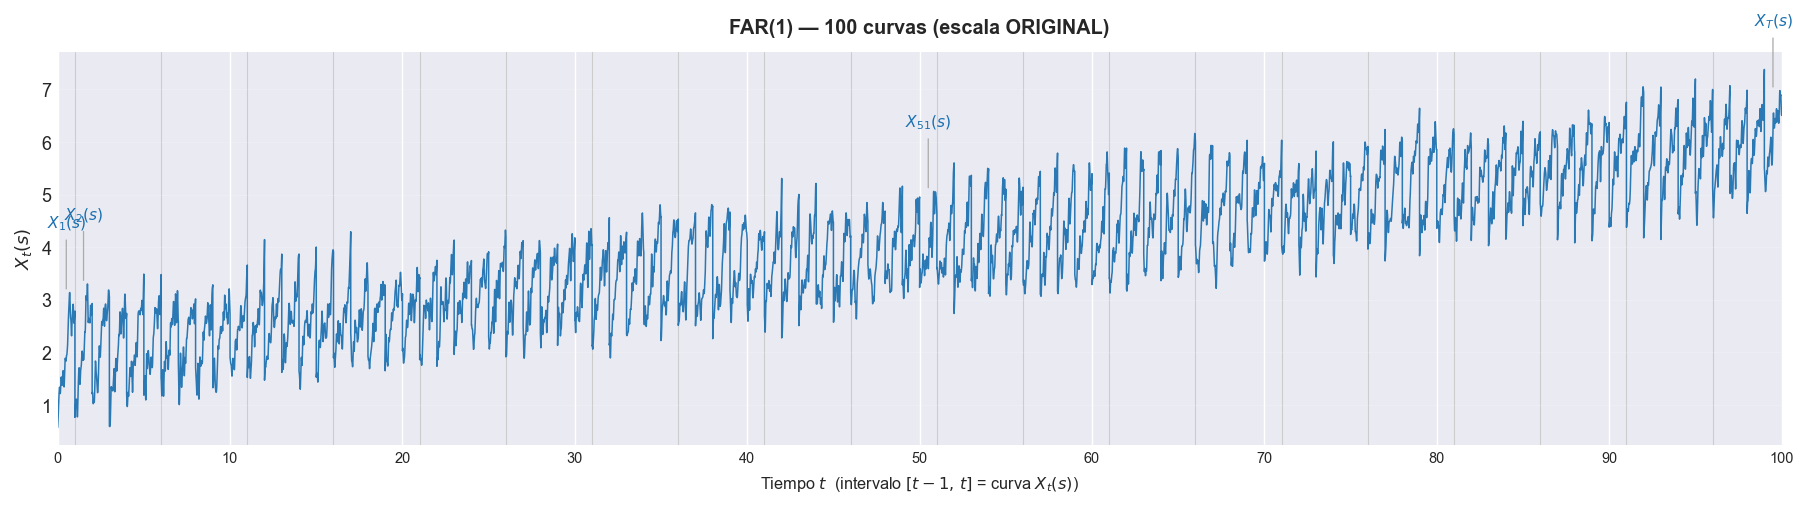

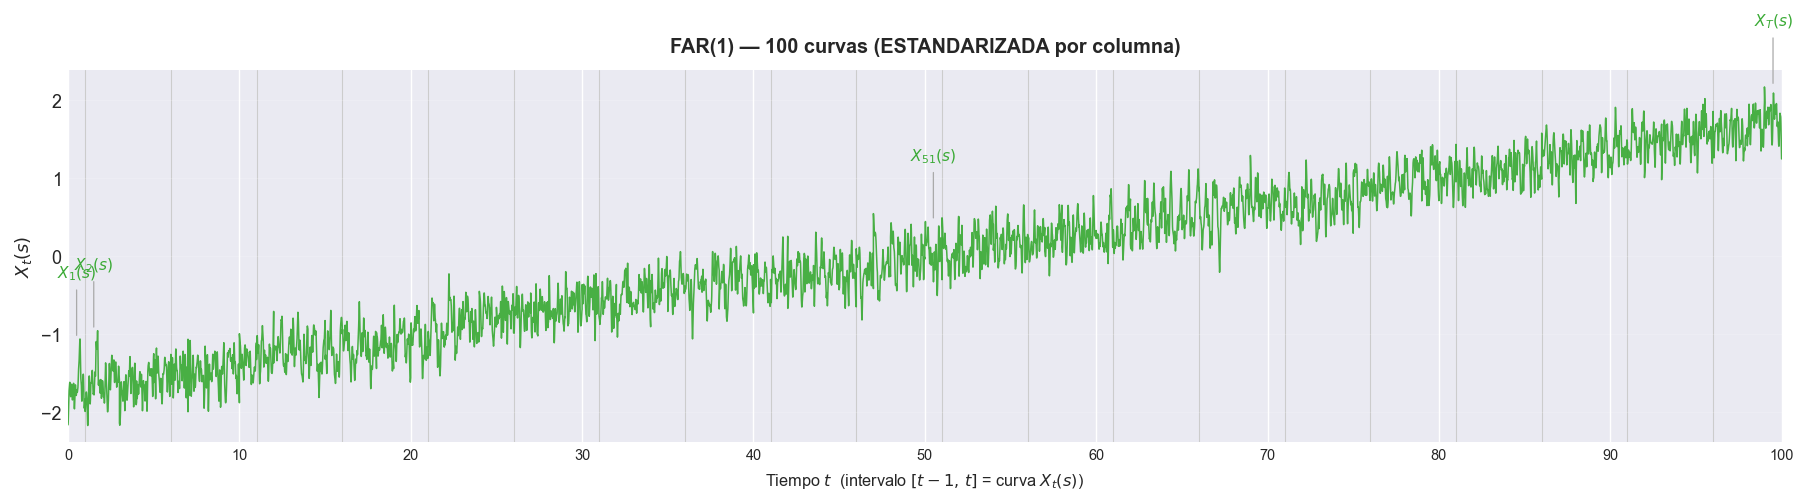

In [40]:
# ── Series de tiempo funcionales: original vs estandarizada ──────────────────
fig = plot_fts_empirical(
    X_raw, domain.grid,
    highlight_idx=highlight_idx,
    title=f"FAR(1) — {T} curvas (escala ORIGINAL)",
    separator_every=5,
    save_path=str(PATHS["out"] / "05_fts_empirica_original.png"),
)
plt.show()

fig = plot_fts_empirical(
    X, domain.grid,
    highlight_idx=highlight_idx,
    color="#3aaa35",
    title=f"FAR(1) — {T} curvas (ESTANDARIZADA por columna)",
    separator_every=5,
    save_path=str(PATHS["out"] / "06_fts_empirica_std.png"),
)
plt.show()

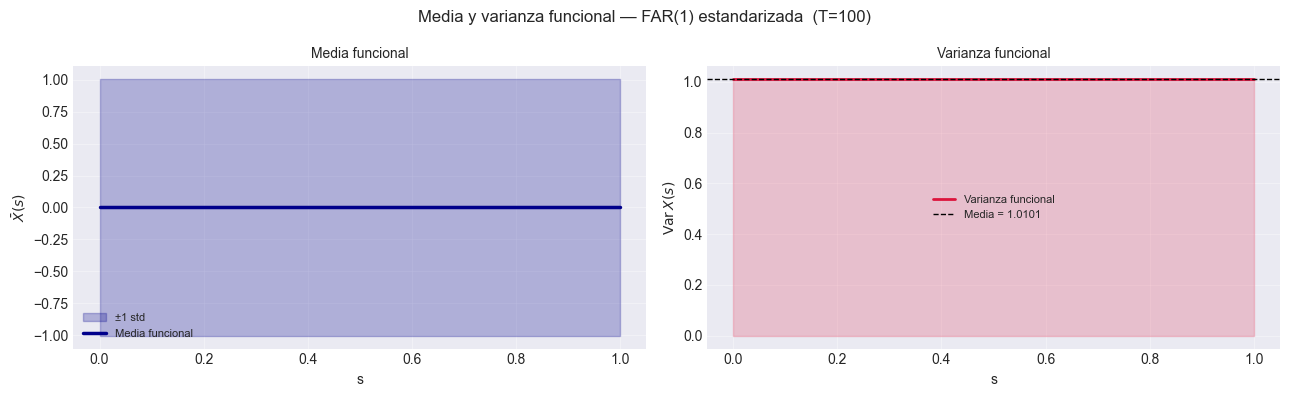

In [41]:
# ── Media y varianza funcional de X estandarizada ────────────────────────────
fig = plot_mean_and_variance(
    X, domain.grid,
    show_std1 = True,
    title     = "Media y varianza funcional — FAR(1) estandarizada",
    save_path = str(PATHS["out"] / "07_media_varianza_std.png"),
)
plt.show()

# 3. Representación funcional B-spline

## 3.1 Selección de n_basis × order

In [42]:
N_BASIS_RANGE = range(2, min(20, T // 2))
ORDER_RANGE   = range(2, 5)
selection_records = []

for order in ORDER_RANGE:
    for nb in N_BASIS_RANGE:
        if nb < order:
            continue
        try:
            fr_tmp = FunctionalRepresentation(method="bspline", n_basis=nb, order=order)
            TH_tmp = fr_tmp.fit_transform(X, domain.grid)
            X_rec  = fr_tmp.reconstruct(TH_tmp)
            ss_res = np.sum((X - X_rec) ** 2)
            ss_tot = np.sum((X - X.mean(axis=0, keepdims=True)) ** 2)
            vr     = 1.0 - ss_res / ss_tot
            rmse_c = np.sqrt(np.mean((X - X_rec) ** 2, axis=1))
            selection_records.append({
                "n_basis": nb, "order": order, "var_retained": vr,
                "rmse_mean": rmse_c.mean(), "rmse_max": rmse_c.max(),
            })
        except Exception as e:
            print(f"  [SKIP] n_basis={nb}, order={order}: {e}")

sel_df   = pd.DataFrame(selection_records)
best_idx = sel_df.sort_values(["var_retained", "n_basis"], ascending=[False, True]).index[0]
best_row = sel_df.loc[best_idx]
nb_best  = int(best_row["n_basis"])
ord_best = int(best_row["order"])

display(sel_df.style
    .format({"var_retained": "{:.4%}", "rmse_mean": "{:.6f}", "rmse_max": "{:.6f}"})
    .background_gradient(subset=["var_retained"], cmap="YlGn")
    .background_gradient(subset=["rmse_mean"],    cmap="YlOrRd_r"))
print(f"\nRecomendación: n_basis={nb_best}, order={ord_best}, var_retained={best_row['var_retained']:.4%}")

,n_basis,order,var_retained,rmse_mean,rmse_max
0,2,2,96.5558%,0.183524,0.245860
1,3,2,96.9487%,0.172352,0.241151
2,4,2,97.5181%,0.155971,0.225408
3,5,2,97.6544%,0.151524,0.206602
4,6,2,98.0226%,0.139246,0.190020
5,7,2,98.2891%,0.129188,0.185074
6,8,2,98.4959%,0.120962,0.171203
7,9,2,98.5879%,0.116994,0.160505
8,10,2,98.7487%,0.110270,0.151500
9,11,2,98.9320%,0.101218,0.165913



Recomendación: n_basis=19, order=3, var_retained=99.6489%


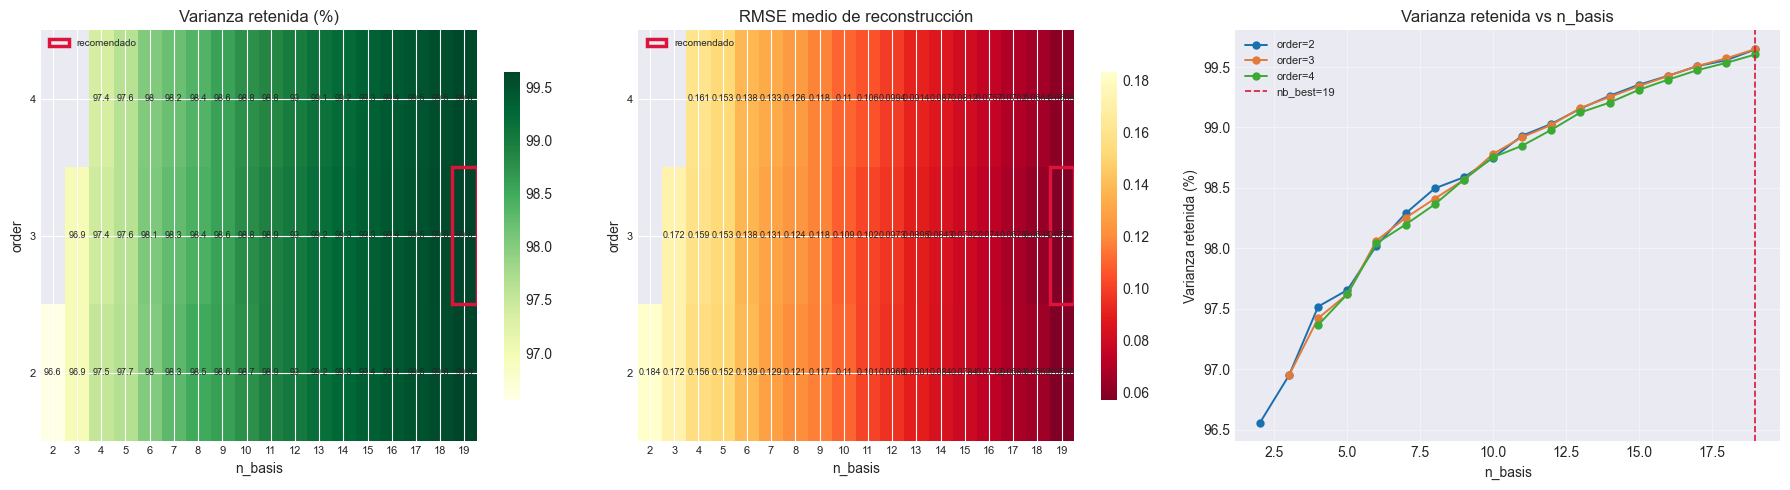

In [43]:
# ── Heatmaps + curva de varianza retenida ────────────────────────────────────
vr_pivot   = sel_df.pivot(index="order", columns="n_basis", values="var_retained")
rmse_pivot = sel_df.pivot(index="order", columns="n_basis", values="rmse_mean")
best_nb_idx  = list(vr_pivot.columns).index(nb_best)
best_ord_idx = list(vr_pivot.index).index(ord_best)
orders_list  = sorted(sel_df["order"].unique())
colors_ord   = ["#1a6faf", "#e07b39", "#3aaa35", "#9b59b6"]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, pivot, cmap, label in [
    (axes[0], vr_pivot*100,   "YlGn",    "Varianza retenida (%)"),
    (axes[1], rmse_pivot,     "YlOrRd_r", "RMSE medio de reconstrucción"),
]:
    im = ax.imshow(pivot.values, aspect="auto", cmap=cmap, origin="lower")
    ax.set_xticks(range(len(pivot.columns))); ax.set_xticklabels(pivot.columns, fontsize=8)
    ax.set_yticks(range(len(pivot.index)));   ax.set_yticklabels(pivot.index,   fontsize=8)
    ax.set_xlabel("n_basis"); ax.set_ylabel("order"); ax.set_title(label)
    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            v = pivot.values[i, j]
            if not np.isnan(v):
                ax.text(j, i, f"{v:.3g}", ha="center", va="center", fontsize=6.5)
    ax.add_patch(plt.Rectangle(
        (best_nb_idx-.5, best_ord_idx-.5), 1, 1,
        fill=False, edgecolor="crimson", lw=2.5, label="recomendado"))
    ax.legend(fontsize=7, loc="upper left")
    plt.colorbar(im, ax=ax, shrink=0.8)

for i, ord_ in enumerate(orders_list):
    sub = sel_df[sel_df["order"] == ord_].sort_values("n_basis")
    axes[2].plot(sub["n_basis"], sub["var_retained"]*100, marker="o", lw=1.4, ms=5,
                 color=colors_ord[i % 4], label=f"order={ord_}")
axes[2].axvline(nb_best, color="crimson", ls="--", lw=1.2, label=f"nb_best={nb_best}")
axes[2].set_xlabel("n_basis"); axes[2].set_ylabel("Varianza retenida (%)")
axes[2].set_title("Varianza retenida vs n_basis"); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.4)

plt.tight_layout()
fig.savefig(PATHS["out"] / "08_seleccion_basis.png", dpi=130, bbox_inches="tight")
plt.show()

## 3.2 Ajuste y visualización de la representación funcional

THETA shape: (100, 10)  (T=100, K=10)


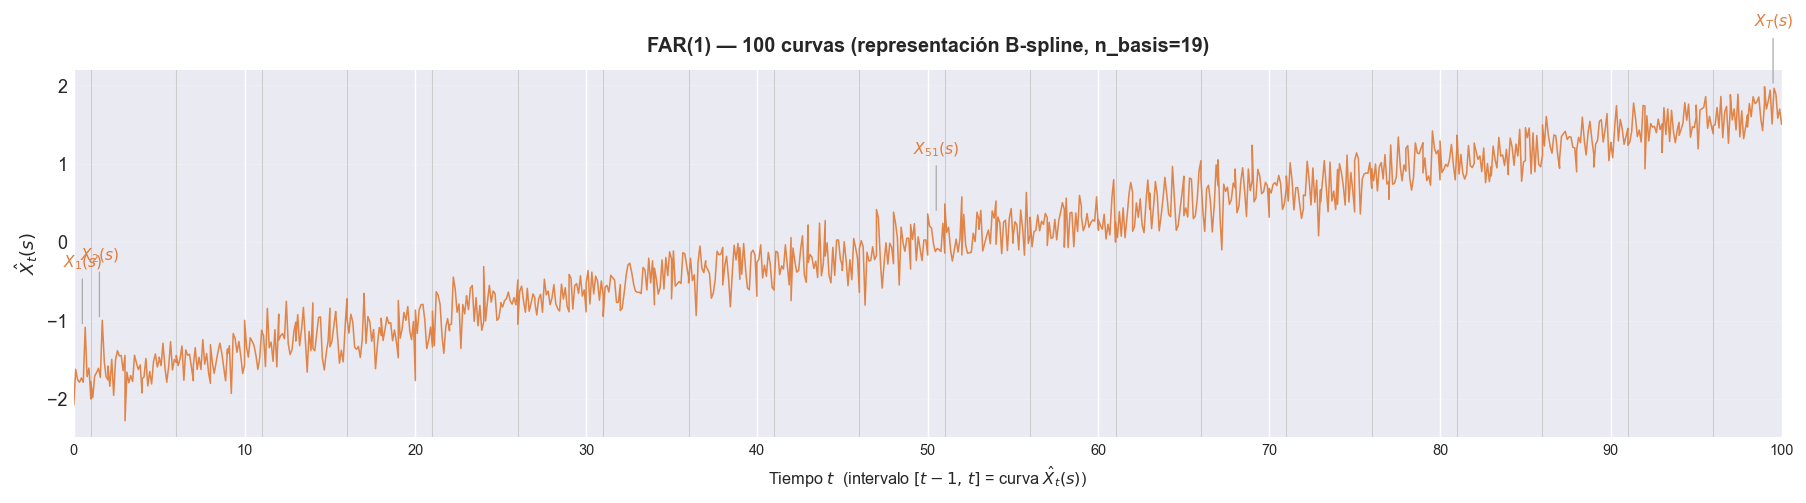

In [ ]:
fr    = FunctionalRepresentation(method="bspline", n_basis=10, order=2)
THETA = fr.fit_transform(X, domain.grid)
print(f"THETA shape: {THETA.shape}  (T={THETA.shape[0]}, K={THETA.shape[1]})")

# ── Serie de tiempo funcional con representación B-spline ────────────────────
fig = plot_fts_functional(
    X, domain.grid,
    fr              = fr,
    highlight_idx   = highlight_idx,
    title           = f"FAR(1) — {T} curvas (repr. B-spline, n_basis={nb_best}, order={ord_best})",
    separator_every = 5,
    save_path       = str(PATHS["out"] / "09_fts_funcional_bspline.png"),
)
plt.show()

# 4. Construcción de datasets AR(p) por componente

In [44]:
N_LAGS  = 1
T_theta = THETA.shape[0]
K_total = THETA.shape[1]   # componentes disponibles en THETA
T_eff   = T_theta - N_LAGS

print(f"K_total disponibles : {K_total}  (índices 0 … {K_total - 1})")
print(f"T_theta             : {T_theta}")
print(f"N_LAGS              : {N_LAGS}")
print(f"T_eff               : {T_eff}")

K_total disponibles : 10  (índices 0 … 9)
T_theta             : 100
N_LAGS              : 1
T_eff               : 99


In [ ]:
# ════════════════════════════════════════════════════════════════════════════
# SELECCIÓN DE COMPONENTES Y ORDEN AR
# ════════════════════════════════════════════════════════════════════════════
# Edita aquí:
#
#   COMPONENT_IDX : lista de índices (0-based) de los componentes que
#                   entrarán al modelo. El orden de la lista define el
#                   orden en que se modelan y se numeran los DataFrames.
#                   Ejemplos:
#                       [0, 1, 2]            → tres primeros, orden original
#                       [2, 0]               → solo comp 3 y comp 1, en ese orden
#                       list(range(K_total)) → todos
#
#   N_LAGS        : orden AR. Ya definido arriba; descomenta para cambiar.
# ────────────────────────────────────────────────────────────────────────────

COMPONENT_IDX = list(range(K_total))   
N_LAGS      = 1                      

# ── Validación ───────────────────────────────────────────────────────────────
assert len(COMPONENT_IDX) > 0, "COMPONENT_IDX no puede estar vacío."
assert len(COMPONENT_IDX) == len(set(COMPONENT_IDX)), "COMPONENT_IDX tiene índices repetidos."
assert all(0 <= i < K_total for i in COMPONENT_IDX), (
    f"Todos los índices deben estar en [0, {K_total - 1}]. Recibido: {COMPONENT_IDX}"
)

n_components = len(COMPONENT_IDX)

# ── Resumen ───────────────────────────────────────────────────────────────────
print(f"K_total disponibles : {K_total}")
print(f"Componentes usados  : {n_components}  →  índices {COMPONENT_IDX}")
print(f"Orden AR (N_LAGS)   : {N_LAGS}")
print()
print(f"  {'k_modelo':>8}  {'idx_THETA':>10}  {'nombre_resp':>14}")
print(f"  {'─'*8}  {'─'*10}  {'─'*14}")
for k_model, idx in enumerate(COMPONENT_IDX):
    print(f"  {k_model:>8}  {idx:>10}  {'theta_' + str(idx + 1):>14}")

K_total disponibles : 10
Componentes usados  : 10  →  índices [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Orden AR (N_LAGS)   : 1

  k_modelo   idx_THETA     nombre_resp
  ────────  ──────────  ──────────────
         0           0         theta_1
         1           1         theta_2
         2           2         theta_3
         3           3         theta_4
         4           4         theta_5
         5           5         theta_6
         6           6         theta_7
         7           7         theta_8
         8           8         theta_9
         9           9        theta_10


In [46]:
# ── Construcción de DataFrames AR(p) ─────────────────────────────────────────
THETA_sel = THETA[:, COMPONENT_IDX]   # (T_theta, n_components)

cov_names = [
    f"theta_{COMPONENT_IDX[j] + 1}_lag{lag}"
    for lag in range(1, N_LAGS + 1)
    for j in range(n_components)
]

dfs = {}
for k in range(n_components):
    y_col  = THETA_sel[N_LAGS:, k]
    X_cols = np.hstack([
        THETA_sel[N_LAGS - lag: T_theta - lag, :]
        for lag in range(1, N_LAGS + 1)
    ])
    resp_name = f"theta_{COMPONENT_IDX[k] + 1}"
    dfs[k] = pd.DataFrame(
        np.column_stack([y_col, X_cols]),
        columns=[resp_name] + cov_names,
    )
    print(f"dfs[{k}]  resp='{resp_name}'  shape={dfs[k].shape}")

dfs[0]  resp='theta_1'  shape=(99, 11)
dfs[1]  resp='theta_2'  shape=(99, 11)
dfs[2]  resp='theta_3'  shape=(99, 11)
dfs[3]  resp='theta_4'  shape=(99, 11)
dfs[4]  resp='theta_5'  shape=(99, 11)
dfs[5]  resp='theta_6'  shape=(99, 11)
dfs[6]  resp='theta_7'  shape=(99, 11)
dfs[7]  resp='theta_8'  shape=(99, 11)
dfs[8]  resp='theta_9'  shape=(99, 11)
dfs[9]  resp='theta_10'  shape=(99, 11)


# 5. Especificación de hiperparámetros y ajuste MCMC

In [47]:
MCMC_CONFIG = {"nsim": 4000, "burn": 2000, "N": 15, "M": 75}
N_CHAINS    = 2
CHAIN_SEEDS = [SEED + c * 100 for c in range(N_CHAINS)]
BURN        = int(MCMC_CONFIG["burn"])
print(f"MCMC_CONFIG : {MCMC_CONFIG}")
print(f"N_CHAINS    : {N_CHAINS}  |  CHAIN_SEEDS: {CHAIN_SEEDS}")

MCMC_CONFIG : {'nsim': 4000, 'burn': 2000, 'N': 15, 'M': 75}
N_CHAINS    : 2  |  CHAIN_SEEDS: [4123, 4223]


In [48]:
# ════════════════════════════════════════════════════════════════════════════
# HIPERPARÁMETROS — priors heterogéneas por tipo de variable
# ════════════════════════════════════════════════════════════════════════════

# ── Escalares globales ────────────────────────────────────────────────────────
HP_GLOBAL = {
    "atau":  2.0,
    "btau":  0.5,
    "ag":    2.0,
    "bg":    0.5,
    "mumu":  0.0,
    "taumu": 1.0,
    "pwj":   0.5,
}

# ── Priors por tipo de variable ───────────────────────────────────────────────
#   Formato: "tipo": (apij, bpij, mupsij, taupsij)
HP_BY_TYPE = {
    "own_lag1":  (9.0, 1.0,  0.0, 1.0),   # E[π] = 0.90
    "cross_lag": (1.0, 1.0,  0.0, 1.0),   # E[π] = 0.50
}

# ── Clasificador ──────────────────────────────────────────────────────────────
def _classify(name: str, k_model: int, component_idx: list) -> str:
    own_name = f"theta_{component_idx[k_model] + 1}_lag1"
    if name == own_name:
        return "own_lag1"
    if "_lag" in name:
        return "cross_lag"
    return "cross_lag"   # fallback: cualquier variable no reconocida → débil

# ── Construcción automática de HYPERPARAMS_LIST ───────────────────────────────
HYPERPARAMS_LIST = []
for k in range(n_components):
    p = len(cov_names)
    apij    = np.empty(p); bpij    = np.empty(p)
    mupsij  = np.empty(p); taupsij = np.empty(p)

    for j, name in enumerate(cov_names):
        vtype              = _classify(name, k, COMPONENT_IDX)
        a, b, mu, tau      = HP_BY_TYPE[vtype]
        apij[j]    = a;    bpij[j]    = b
        mupsij[j]  = mu;   taupsij[j] = tau

    HYPERPARAMS_LIST.append({**HP_GLOBAL,
                              "apij": apij,     "bpij": bpij,
                              "mupsij": mupsij, "taupsij": taupsij})

# ── Tabla de resumen ──────────────────────────────────────────────────────────
_W = 70
print("═" * _W)
print(f"  HYPERPARAMS_LIST  —  {n_components} componentes × {p} variables")
print("═" * _W)
print(f"  Globales: atau={HP_GLOBAL['atau']} btau={HP_GLOBAL['btau']}  "
      f"ag={HP_GLOBAL['ag']} bg={HP_GLOBAL['bg']}  "
      f"mumu={HP_GLOBAL['mumu']} taumu={HP_GLOBAL['taumu']}  "
      f"pwj={HP_GLOBAL['pwj']}")
print()
for k in range(n_components):
    hp = HYPERPARAMS_LIST[k]
    print(f"  Componente k={k+1}  (theta_{COMPONENT_IDX[k]+1})")
    print(f"  {'Variable':<26} {'Tipo':<12} {'apij':>6} {'bpij':>6} "
          f"{'E[π]':>6} {'mupsij':>8} {'taupsij':>9}")
    print(f"  {'─'*26} {'─'*12} {'─'*6} {'─'*6} "
          f"{'─'*6} {'─'*8} {'─'*9}")
    for j, name in enumerate(cov_names):
        vtype = _classify(name, k, COMPONENT_IDX)
        a  = hp["apij"][j];    b  = hp["bpij"][j]
        mu = hp["mupsij"][j];  tau = hp["taupsij"][j]
        e_pi = a / (a + b)
        marker = "  ◄" if vtype == "own_lag1" else ""
        print(f"  {name:<26} {vtype:<12} {a:>6.1f} {b:>6.1f} "
              f"{e_pi:>6.3f} {mu:>8.1f} {tau:>9.1f}{marker}")
    print()

══════════════════════════════════════════════════════════════════════
  HYPERPARAMS_LIST  —  10 componentes × 10 variables
══════════════════════════════════════════════════════════════════════
  Globales: atau=2.0 btau=0.5  ag=2.0 bg=0.5  mumu=0.0 taumu=1.0  pwj=0.5

  Componente k=1  (theta_1)
  Variable                   Tipo           apij   bpij   E[π]   mupsij   taupsij
  ────────────────────────── ──────────── ────── ────── ────── ──────── ─────────
  theta_1_lag1               own_lag1        9.0    1.0  0.900      0.0       1.0  ◄
  theta_2_lag1               cross_lag       1.0    1.0  0.500      0.0       1.0
  theta_3_lag1               cross_lag       1.0    1.0  0.500      0.0       1.0
  theta_4_lag1               cross_lag       1.0    1.0  0.500      0.0       1.0
  theta_5_lag1               cross_lag       1.0    1.0  0.500      0.0       1.0
  theta_6_lag1               cross_lag       1.0    1.0  0.500      0.0       1.0
  theta_7_lag1               cross_lag     

In [ ]:
models_chains = {k: {} for k in range(n_components)}
fit_times     = {k: {} for k in range(n_components)}

t_global = time.perf_counter()
for k in range(n_components):
    print(f"\n{'='*60}\n  FPC {k+1}  —  ajustando {N_CHAINS} cadenas\n{'='*60}")
    for c, seed_c in enumerate(CHAIN_SEEDS):
        t0 = time.perf_counter()
        m  = PSBP_FD_v2(mcmc_cfg=MCMC_CONFIG, hp=HYPERPARAMS_LIST[k],
                         seed=seed_c, verbose_every=100)
        m.fit(dfs[k])
        elapsed            = time.perf_counter() - t0
        models_chains[k][c] = m
        fit_times[k][c]     = elapsed
        print(f"  [OK] FPC {k+1} | cadena {c+1}  ({elapsed:.1f}s)")

t_total = time.perf_counter() - t_global
print(f"\nTiempo total: {t_total:.1f}s  ({t_total/60:.1f} min)")


  FPC 1  —  ajustando 2 cadenas
  iter 100/4000
  iter 200/4000
  iter 300/4000
  iter 400/4000
  iter 500/4000
  iter 600/4000
  iter 700/4000
  iter 800/4000
  iter 900/4000
  iter 1000/4000
  iter 1100/4000
  iter 1200/4000
  iter 1300/4000
  iter 1400/4000
  iter 1500/4000
  iter 1600/4000
  iter 1700/4000
  iter 1800/4000
  iter 1900/4000
  iter 2000/4000
  iter 2100/4000
  iter 2200/4000
  iter 2300/4000
  iter 2400/4000
  iter 2500/4000
  iter 2600/4000
  iter 2700/4000
  iter 2800/4000
  iter 2900/4000
  iter 3000/4000
  iter 3100/4000
  iter 3200/4000
  iter 3300/4000
  iter 3400/4000
  iter 3500/4000
  iter 3600/4000
  iter 3700/4000
  iter 3800/4000
  iter 3900/4000
  iter 4000/4000
  [OK] FPC 1 | cadena 1  (6397.1s)
  iter 100/4000
  iter 200/4000
  iter 300/4000
  iter 400/4000
  iter 500/4000
  iter 600/4000
  iter 700/4000
  iter 800/4000
  iter 900/4000
  iter 1000/4000
  iter 1100/4000
  iter 1200/4000
  iter 1300/4000
  iter 1400/4000
  iter 1500/4000
  iter 1600/400

# 6. Diagnósticos de convergencia MCMC

| Estadístico | Referencia | Lectura |
|---|---|---|
| ACF(lag) | autocorrelación residual | cerca de 0 ⇒ buena mezcla |
| ESS | Geyer (1992) | ESS ≳ 400 ideal |
| Geweke z | test z entre segmentos | \|z\| < 2 ⇒ no rechazo |
| Gelman-Rubin R̂ | Brooks-Gelman (1998) | R̂ < 1.1 ⇒ convergencia |


## 6.1 Componentes globales

In [ ]:
for k in range(n_components):
    fig = plot_global_components(
        models_chains, k, BURN, N_CHAINS,
        title_prefix = f"FPC {k+1}",
        save_path    = str(PATHS["out"] / f"10_global_comp_k{k+1}.png"),
    )
    plt.show()

In [ ]:
for k in range(n_components):
    fig = plot_active_clusters(
        models_chains, k, BURN, N_CHAINS,
        title_prefix = f"FPC {k+1}",
        save_path    = str(PATHS["out"] / f"11_clusters_activos_k{k+1}.png"),
    )
    plt.show()

## 6.2 Trazas + ACF de β_j y p_j

In [ ]:
for k in range(n_components):
    feat = models_chains[k][0].feature_names_
    fig  = plot_traces_bj(
        models_chains, k, BURN, N_CHAINS,
        feature_names = feat,
        title_prefix  = f"FPC {k+1}",
        save_path     = str(PATHS["out"] / f"12_trazas_bj_k{k+1}.png"),
    )
    plt.show()

In [ ]:
for k in range(n_components):
    feat = models_chains[k][0].feature_names_
    fig  = plot_traces_pj(
        models_chains, k, BURN, N_CHAINS,
        feature_names = feat,
        title_prefix  = f"FPC {k+1}",
        save_path     = str(PATHS["out"] / f"13_trazas_pj_k{k+1}.png"),
    )
    plt.show()

## 6.3 Convergencia completa (traza | ACF | posterior + métricas)

In [ ]:
all_diag_bj = {}
for k in range(n_components):
    feat = models_chains[k][0].feature_names_
    fig, diag = plot_convergence_bj(
        models_chains, k, BURN, N_CHAINS,
        feature_names = feat,
        title_prefix  = f"FPC {k+1}",
        save_path     = str(PATHS["out"] / f"14_convergencia_bj_k{k+1}.png"),
    )
    all_diag_bj[k] = diag
    plt.show()

In [ ]:
all_diag_pj = {}
for k in range(n_components):
    feat = models_chains[k][0].feature_names_
    fig, diag = plot_convergence_pj(
        models_chains, k, BURN, N_CHAINS,
        feature_names = feat,
        title_prefix  = f"FPC {k+1}",
        save_path     = str(PATHS["out"] / f"15_convergencia_pj_k{k+1}.png"),
    )
    all_diag_pj[k] = diag
    plt.show()

In [ ]:
# ── Tabla resumen de convergencia ────────────────────────────────────────────
diag_records = []
for k in range(n_components):
    for rec in all_diag_bj[k]:
        diag_records.append({"componente": k+1, "param": "beta_j", **rec})
    for rec in all_diag_pj[k]:
        diag_records.append({"componente": k+1, "param": "p_j",    **rec})

diag_df = pd.DataFrame(diag_records)
display(
    diag_df.style
    .format({"ess_min": "{:.1f}", "ess_mean": "{:.1f}",
             "geweke_max": "{:+.2f}", "rhat": "{:.3f}"})
    .background_gradient(subset=["rhat"],    cmap="RdYlGn_r", vmin=1.0, vmax=1.2)
    .background_gradient(subset=["ess_min"], cmap="RdYlGn",   vmin=0,   vmax=500)
    .map(lambda v: "font-weight:bold;color:#c0392b" if v is False else "",
         subset=["converge"])
    .set_caption("Diagnósticos MCMC por variable")
)

# 7. Evaluación predictiva

In [ ]:
eval_results = {}
for k in range(n_components):
    m     = models_chains[k][0]
    y_obs = dfs[k].iloc[:, 0].to_numpy()
    y_hat = m.predict(dfs[k])
    incl  = m.inclusion_probs(as_series=True)
    eval_results[k] = {
        "rmse":       m.rmse(dfs[k]),
        "y_hat":      y_hat,
        "y_obs":      y_obs,
        "incl_vec":   incl.values,
        "incl_named": incl,
    }
    print(f"Componente {k+1}:  inRMSE = {eval_results[k]['rmse']:.6f}")
    for name, val in incl.items():
        print(f"    P(γ=1 | {name:<22}) = {val:.4f}{'  *' if val > 0.5 else ''}")

## 7.1 Scatter θ_obs vs θ_hat

In [ ]:
fig = plot_scatter_theta(
    eval_results,
    n_components = n_components,
    save_path    = str(PATHS["out"] / "16_scatter_theta.png"),
)
plt.show()

## 7.2 Comparativa de reconstrucción funcional (snapshots)

In [ ]:
fig, recon_metrics = plot_functional_comparison(
    eval_results,
    fr           = fr,
    domain_grid  = domain.grid,
    X_true       = X,
    n_components = n_components,
    n_lags       = N_LAGS,
    n_snapshots  = 5,
    save_path    = str(PATHS["out"] / "17_recon_funcional_snapshots.png"),
)
plt.show()
print(recon_metrics)

In [ ]:
# ── Snapshots adicionales ─────────────────────────────────────────────────────
fig, _ = plot_functional_comparison(
    eval_results,
    fr           = fr,
    domain_grid  = domain.grid,
    X_true       = X,
    n_components = n_components,
    n_lags       = N_LAGS,
    t_indices    = [5, 15, 30, 50, 80],
    title        = "Reconstrucción funcional — ejemplos adicionales",
    save_path    = str(PATHS["out"] / "18_recon_funcional_extra.png"),
)
plt.show()

## 7.3 Comparativa de serie de tiempo completa (todo T)

In [ ]:
# ── Construir X_pred_repr (todo T_eff) ───────────────────────────────────────
THETA_pred  = np.column_stack([eval_results[k]["y_hat"] for k in range(n_components)])
X_pred_repr = fr.reconstruct(THETA_pred)   # (T_eff, G)
print(f"X_pred_repr shape: {X_pred_repr.shape}  (T_eff={T_eff}, G={G})")

In [ ]:
# ── Comparativa completa en todo T ───────────────────────────────────────────
fig, ts_metrics = plot_fts_comparison(
    X, domain.grid,
    fr           = fr,
    X_pred_repr  = X_pred_repr,
    n_lags       = N_LAGS,
    highlight_idx = highlight_idx,
    separator_every = 5,
    title        = (f"Comparativa serie funcional — empírica | B-spline | PSBP  ($T={T}$)"),
    save_path    = str(PATHS["out"] / "19_fts_comparativa_completa.png"),
)
plt.show()
print(ts_metrics)

# 8. Persistencia de resultados

Guardamos dos archivos JSON en `reports/simulaciones/metrics/`:

| Archivo | Contenido |
|---|---|
| `{EXPERIMENT_ID}_metrics.json` | Diagnósticos MCMC + RMSE por componente + métricas de reconstrucción |
| `{EXPERIMENT_ID}_config.json`  | Parámetros del experimento para reproducibilidad |

Las figuras ya se guardaron durante el notebook vía `save_path`.


In [ ]:
# ── Serializador robusto de tipos numpy ───────────────────────────────────────
def _to_python(obj):
    """
    Convierte recursivamente tipos numpy / Python no serializables a tipos
    nativos compatibles con json.dump.

    Cubre:
        np.integer, np.floating, np.bool_  → int, float, bool
        np.ndarray                          → list (recursivo)
        dict, list, tuple                   → mismo tipo, recursivo
        bool nativo                         → bool  (debe ir antes que int)
        Cualquier otro                      → pass-through
    """
    if isinstance(obj, bool):            return obj               # antes de int
    if isinstance(obj, np.bool_):        return bool(obj)
    if isinstance(obj, np.integer):      return int(obj)
    if isinstance(obj, np.floating):     return float(obj)
    if isinstance(obj, np.ndarray):      return [_to_python(v) for v in obj.tolist()]
    if isinstance(obj, dict):            return {k: _to_python(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):   return [_to_python(v) for v in obj]
    return obj

print("_to_python listo.")

In [ ]:
# ── Construir payload de métricas ────────────────────────────────────────────
metrics_out = _to_python({
    "experiment_id":  EXPERIMENT_ID,
    "timestamp":      TIMESTAMP,
    "n_components":   n_components,
    "n_lags":         N_LAGS,
    "mcmc_config":    MCMC_CONFIG,
    "n_chains":       N_CHAINS,
    "burn":           BURN,
    "fit_times_s":    fit_times,
    "convergence_bj": {k: all_diag_bj[k] for k in all_diag_bj},
    "convergence_pj": {k: all_diag_pj[k] for k in all_diag_pj},
    "rmse_per_component": {
        k: eval_results[k]["rmse"] for k in range(n_components)
    },
    "recon_metrics":  recon_metrics,
    "ts_metrics":     ts_metrics,
    "inclusion_probs": {
        k: dict(eval_results[k]["incl_named"]) for k in range(n_components)
    },
})

metrics_path = PATHS["out"] / f"{EXPERIMENT_ID}_metrics.json"
with open(metrics_path, "w", encoding="utf-8") as f:
    json.dump(metrics_out, f, indent=2, ensure_ascii=False)
print(f"Métricas  → {metrics_path}  ({metrics_path.stat().st_size / 1024:.1f} KB)")

In [ ]:
# ── Construir payload de configuración ───────────────────────────────────────
config_out = _to_python({
    "experiment_id":  EXPERIMENT_ID,
    "timestamp":      TIMESTAMP,
    "seed":           SEED,
    "far_params":     FAR_PARAMS,
    "standarize":     STANDARIZE_CONFIG,
    "bspline":        {"n_basis": nb_best, "order": ord_best},
    "mcmc":           MCMC_CONFIG,
    "n_chains":       N_CHAINS,
    "chain_seeds":    CHAIN_SEEDS,
    "n_lags":         N_LAGS,
    "n_components":   n_components,
})

config_path = PATHS["out"] / f"{EXPERIMENT_ID}_config.json"
with open(config_path, "w", encoding="utf-8") as f:
    json.dump(config_out, f, indent=2, ensure_ascii=False)
print(f"Config    → {config_path}  ({config_path.stat().st_size / 1024:.1f} KB)")

In [ ]:
# ── Verificación de integridad: re-leer y parsear los dos JSON ────────────────
for path in [metrics_path, config_path]:
    with open(path, "r", encoding="utf-8") as f:
        loaded = json.load(f)
    print(f"OK  {path.name}  ({len(loaded)} claves raíz)")

In [ ]:
# ── Resumen final ─────────────────────────────────────────────────────────────
figures_saved = sorted(PATHS["out"].glob("*.png"))
metrics_saved = sorted(PATHS["out"].glob("*.json"))

print("\n" + "="*65)
print(f"  Experimento  : {EXPERIMENT_ID}")
print(f"  Componentes  : {n_components}  |  N_LAGS: {N_LAGS}")
print(f"  Cadenas      : {N_CHAINS}       |  Burn-in: {BURN}")
print("─"*65)
print("  RMSE in-sample por componente:")
for k in range(n_components):
    print(f"    k={k+1}  →  {eval_results[k]['rmse']:.6f}")
print("─"*65)
print(f"  RMSE repr  (B-spline) : {recon_metrics.get('rmse_repr',  float('nan')):.6f}")
print(f"  RMSE model (PSBP→func): {recon_metrics.get('rmse_model', float('nan')):.6f}")
print(f"  RMSE total            : {recon_metrics.get('rmse_total', float('nan')):.6f}")
print("─"*65)
n_conv = sum(
    1 for k in range(n_components)
    for rec in all_diag_bj[k] + all_diag_pj[k]
    if rec.get("converge", False)
)
n_total = sum(len(all_diag_bj[k]) + len(all_diag_pj[k]) for k in range(n_components))
print(f"  Convergencia : {n_conv}/{n_total} parámetros (R̂<1.1 & ESS>100 & |G|<2)")
print("─"*65)
print(f"  Figuras guardadas : {len(figures_saved)}  →  {PATHS['out']}")
print(f"  JSONs guardados   : {len(metrics_saved)}  →  {PATHS['out']}")
print("="*65)